# AML Transaction Analytics

This notebook performs four levels of analytics on the transaction dataset:

1. **Descriptive analytics** — What happened?
2. **Diagnostic analytics** — Why did it happen?
3. **Predictive analytics** — Which transactions should be reviewed first?
4. **Prescriptive analytics** — What actions should the compliance team take?

> Important limitation: the dataset contains only one laundering-labelled transaction. Therefore, a conventional supervised classification model would not be statistically reliable. The predictive section uses anomaly detection for review prioritization.


## 1. Setup

Upload `dataset.csv` to the same folder as this notebook, or update `DATA_PATH` below.


In [1]:
# Install packages when running in Google Colab.
# Uncomment the next line if required.
# !pip install pandas numpy matplotlib scikit-learn openpyxl

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction import DictVectorizer

warnings.filterwarnings("ignore")

DATA_PATH = Path("dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "dataset.csv was not found. Upload the file beside this notebook "
        "or change DATA_PATH to the correct location."
    )

print("Dataset path:", DATA_PATH.resolve())


Dataset path: C:\Users\home\Downloads\Team-Management-System\IBM AML\dataset.csv


## 2. Load and inspect the data


In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (500, 11)


,Timestamp,From Bank,Account,To Bank,Account_4,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,9/1/2022 0:14:00,1,8008093B0,1,8008093B0,3480926.29,US Dollar,3480926.29,US Dollar,Reinvestment,0
1,9/1/2022 0:01:00,1,802921370,1,802921370,13743.28,US Dollar,13743.28,US Dollar,Reinvestment,0
2,9/1/2022 9:18:00,1,800DB4EF0,1,800DB4EF0,19.61,US Dollar,19.61,US Dollar,Reinvestment,0
3,9/1/2022 17:57:00,1,80D2D6E70,1,80D2D6E70,7.92,US Dollar,7.92,US Dollar,Reinvestment,0
4,9/6/2022 4:10:00,1,8003080E0,1,800580F30,16.76,US Dollar,16.76,US Dollar,Credit Card,0


In [3]:
print("Column names:")
for column in df.columns:
    print("-", column)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))


Column names:
- Timestamp
- From Bank
- Account
- To Bank
- Account_4
- Amount Received
- Receiving Currency
- Amount Paid
- Payment Currency
- Payment Format
- Is Laundering

Data types:


,dtype
Timestamp,object
From Bank,int64
Account,object
To Bank,int64
Account_4,object
Amount Received,float64
Receiving Currency,object
Amount Paid,float64
Payment Currency,object
Payment Format,object



Missing values:


,missing_values
Timestamp,0
From Bank,0
Account,0
To Bank,0
Account_4,0
Amount Received,0
Receiving Currency,0
Amount Paid,0
Payment Currency,0
Payment Format,0


## 3. Data preparation and feature engineering


In [4]:
# Convert the timestamp into a datetime value.
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

numeric_columns = [
    "From Bank",
    "To Bank",
    "Amount Received",
    "Amount Paid",
    "Is Laundering",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Derived analytical features.
df["Amount Difference"] = df["Amount Received"] - df["Amount Paid"]
df["Absolute Difference"] = df["Amount Difference"].abs()
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day_name()
df["Day of Week"] = df["Timestamp"].dt.dayofweek
df["Cross-bank"] = (df["From Bank"] != df["To Bank"]).astype(int)
df["Currency Mismatch"] = (
    df["Receiving Currency"] != df["Payment Currency"]
).astype(int)

print("Prepared shape:", df.shape)
display(df.head())


Prepared shape: (500, 18)


,Timestamp,From Bank,Account,To Bank,Account_4,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount Difference,Absolute Difference,Hour,Day,Day of Week,Cross-bank,Currency Mismatch
0,2022-09-01 00:14:00,1,8008093B0,1,8008093B0,3480926.29,US Dollar,3480926.29,US Dollar,Reinvestment,0,0.0,0.0,0,Thursday,3,0,0
1,2022-09-01 00:01:00,1,802921370,1,802921370,13743.28,US Dollar,13743.28,US Dollar,Reinvestment,0,0.0,0.0,0,Thursday,3,0,0
2,2022-09-01 09:18:00,1,800DB4EF0,1,800DB4EF0,19.61,US Dollar,19.61,US Dollar,Reinvestment,0,0.0,0.0,9,Thursday,3,0,0
3,2022-09-01 17:57:00,1,80D2D6E70,1,80D2D6E70,7.92,US Dollar,7.92,US Dollar,Reinvestment,0,0.0,0.0,17,Thursday,3,0,0
4,2022-09-06 04:10:00,1,8003080E0,1,800580F30,16.76,US Dollar,16.76,US Dollar,Credit Card,0,0.0,0.0,4,Tuesday,1,0,0


# Part A — Descriptive Analytics


Descriptive analytics summarizes the size, distribution, frequency, and major characteristics of the transaction data.


In [5]:
summary = pd.DataFrame({
    "Metric": [
        "Transactions",
        "Laundering-labelled transactions",
        "Labelled laundering rate",
        "Total amount received",
        "Total amount paid",
        "Median amount received",
        "Median amount paid",
        "Mean amount received",
        "Mean amount paid",
        "95th percentile received",
        "99th percentile received",
        "Maximum amount received",
        "Maximum amount paid",
        "Cross-bank transactions",
        "Currency-mismatch transactions",
    ],
    "Value": [
        len(df),
        int(df["Is Laundering"].sum()),
        df["Is Laundering"].mean(),
        df["Amount Received"].sum(),
        df["Amount Paid"].sum(),
        df["Amount Received"].median(),
        df["Amount Paid"].median(),
        df["Amount Received"].mean(),
        df["Amount Paid"].mean(),
        df["Amount Received"].quantile(0.95),
        df["Amount Received"].quantile(0.99),
        df["Amount Received"].max(),
        df["Amount Paid"].max(),
        int(df["Cross-bank"].sum()),
        int(df["Currency Mismatch"].sum()),
    ],
})

display(summary)


,Metric,Value
0,Transactions,5.000000e+02
1,Laundering-labelled transactions,1.000000e+00
2,Labelled laundering rate,2.000000e-03
3,Total amount received,2.208635e+10
4,Total amount paid,1.142072e+10
5,Median amount received,1.173980e+03
6,Median amount paid,1.189795e+03
7,Mean amount received,4.417271e+07
8,Mean amount paid,2.284144e+07
9,95th percentile received,3.482317e+06


In [6]:
def grouped_transaction_summary(column):
    result = (
        df.groupby(column, dropna=False)
        .agg(
            Transactions=("Is Laundering", "size"),
            Total_Received=("Amount Received", "sum"),
            Mean_Received=("Amount Received", "mean"),
            Median_Received=("Amount Received", "median"),
            Laundering_Labels=("Is Laundering", "sum"),
            Currency_Mismatches=("Currency Mismatch", "sum"),
        )
        .reset_index()
    )
    result["Share"] = result["Transactions"] / len(df)
    return result.sort_values("Transactions", ascending=False)

payment_format_summary = grouped_transaction_summary("Payment Format")
receiving_currency_summary = grouped_transaction_summary("Receiving Currency")
destination_bank_summary = grouped_transaction_summary("To Bank")
day_summary = grouped_transaction_summary("Day")

print("Payment format summary")
display(payment_format_summary)

print("Receiving currency summary")
display(receiving_currency_summary)

print("Destination bank summary")
display(destination_bank_summary)

print("Day summary")
display(day_summary)


Payment format summary


,Payment Format,Transactions,Total_Received,Mean_Received,Median_Received,Laundering_Labels,Currency_Mismatches,Share
4,Reinvestment,154,5.885007e+07,3.821433e+05,1193.565,0,0,0.308
0,ACH,117,1.382072e+10,1.181258e+08,1602.660,1,75,0.234
2,Cheque,111,8.043656e+09,7.246537e+07,1296.710,0,0,0.222
3,Credit Card,80,9.481891e+07,1.185236e+06,887.910,0,0,0.160
1,Cash,22,1.935328e+07,8.796945e+05,3006.605,0,0,0.044
5,Wire,16,4.895724e+07,3.059828e+06,61.925,0,0,0.032


Receiving currency summary


,Receiving Currency,Transactions,Total_Received,Mean_Received,Median_Received,Laundering_Labels,Currency_Mismatches,Share
7,US Dollar,412,1.543985e+08,3.747537e+05,1.095065e+03,1,0,0.824
2,Euro,47,3.226814e+07,6.865562e+05,4.586500e+02,0,47,0.094
3,Ruble,19,1.440344e+10,7.580757e+08,2.146544e+06,0,8,0.038
8,Yen,6,7.490473e+09,1.248412e+09,9.516161e+08,0,6,0.012
0,Brazil Real,3,1.721675e+05,5.738916e+04,8.600126e+04,0,3,0.006
1,Canadian Dollar,3,2.416640e+03,8.055467e+02,2.960000e+01,0,1,0.006
4,Rupee,3,5.418441e+06,1.806147e+06,1.611498e+06,0,3,0.006
5,Swiss Franc,3,3.323000e+02,1.107667e+02,1.280500e+02,0,3,0.006
6,UK Pound,2,1.508320e+05,7.541602e+04,7.541602e+04,0,2,0.004
9,Yuan,2,3.266954e+04,1.633477e+04,1.633477e+04,0,2,0.004


Destination bank summary


,To Bank,Transactions,Total_Received,Mean_Received,Median_Received,Laundering_Labels,Currency_Mismatches,Share
0,1,420,1.096386e+10,2.610444e+07,1173.98,1,75,0.840
4,10,67,7.622279e+06,1.137654e+05,773.77,0,0,0.134
1,4,7,1.111097e+10,1.587282e+09,92760199.31,0,0,0.014
3,9,4,3.896733e+06,9.741832e+05,741230.51,0,0,0.008
2,8,2,5.920000e+01,2.960000e+01,29.60,0,0,0.004


Day summary


,Day,Transactions,Total_Received,Mean_Received,Median_Received,Laundering_Labels,Currency_Mismatches,Share
4,Thursday,241,6.827776e+09,2.833102e+07,1348.870,0,19,0.482
0,Friday,87,1.473908e+08,1.694147e+06,890.420,0,19,0.174
1,Monday,43,5.859404e+09,1.362652e+08,3419.880,0,9,0.086
2,Saturday,43,8.837528e+09,2.055239e+08,590.310,1,11,0.086
5,Tuesday,34,1.026876e+08,3.020224e+06,3218.310,0,6,0.068
6,Wednesday,32,1.171162e+07,3.659883e+05,736.345,0,6,0.064
3,Sunday,20,2.998561e+08,1.499280e+07,1009.760,0,5,0.040


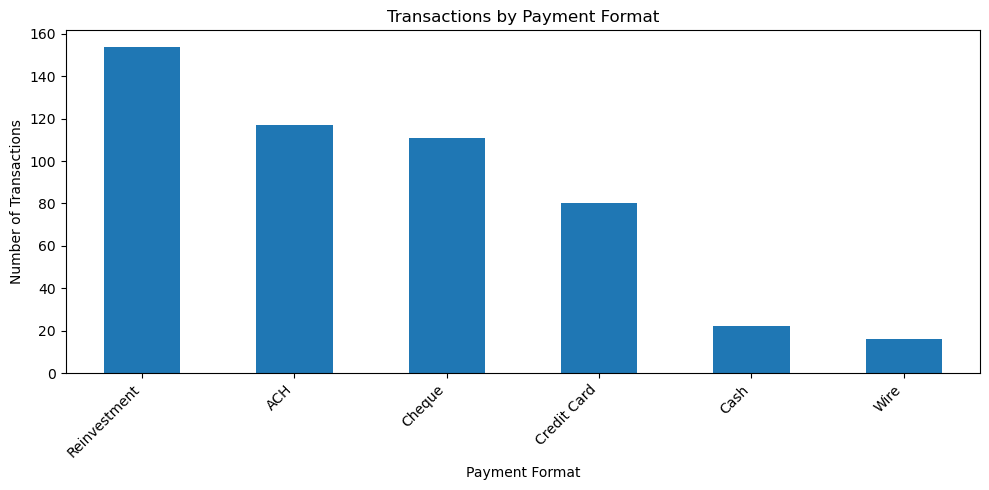

In [7]:
# Transaction distribution by payment format.
payment_counts = df["Payment Format"].value_counts()

plt.figure(figsize=(10, 5))
payment_counts.plot(kind="bar")
plt.title("Transactions by Payment Format")
plt.xlabel("Payment Format")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


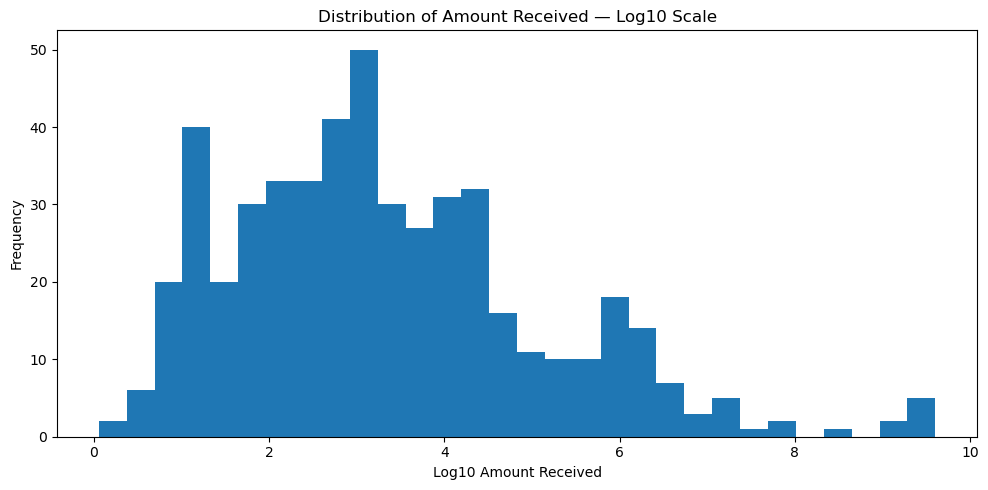

In [8]:
# Amount distribution is shown on a logarithmic scale because of extreme skew.
positive_amounts = df.loc[df["Amount Received"] > 0, "Amount Received"]

plt.figure(figsize=(10, 5))
plt.hist(np.log10(positive_amounts), bins=30)
plt.title("Distribution of Amount Received — Log10 Scale")
plt.xlabel("Log10 Amount Received")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [9]:
# Top transactions by received amount.
top_amounts = df.nlargest(15, "Amount Received")[
    [
        "Timestamp",
        "Account",
        "To Bank",
        "Account_4",
        "Amount Received",
        "Receiving Currency",
        "Payment Format",
        "Is Laundering",
    ]
]

display(top_amounts)


,Timestamp,Account,To Bank,Account_4,Amount Received,Receiving Currency,Payment Format,Is Laundering
420,2022-09-05 14:08:00,801227860,4,806ABFC50,4.016071e+09,Ruble,Cheque,0
422,2022-09-03 00:04:00,801227860,4,806ABFC50,4.016071e+09,Ruble,Cheque,0
50,2022-09-08 01:13:00,800BB2240,1,800BB2240,3.739865e+09,Yen,ACH,0
323,2022-09-01 22:15:00,801227860,1,801227860,2.981124e+09,Ruble,ACH,0
421,2022-09-03 00:12:00,801227860,4,806ABFC50,2.981124e+09,Ruble,ACH,0
157,2022-09-05 04:07:00,800B0E670,1,800B0E670,1.833519e+09,Yen,ACH,0
361,2022-09-03 23:06:00,800B0E670,1,800B0E670,1.833519e+09,Yen,ACH,0
281,2022-09-04 21:50:00,801754760,1,801754760,2.973927e+08,Ruble,ACH,0
426,2022-09-06 07:13:00,801227860,4,806ABFC50,9.276020e+07,Ruble,Credit Card,0
100,2022-09-02 00:35:00,80140FA20,1,80140FA20,6.971300e+07,Yen,ACH,0


# Part B — Diagnostic Analytics


Diagnostic analytics investigates the reasons behind the descriptive patterns and identifies data limitations that affect interpretation.


In [10]:
diagnostic_metrics = {
    "Mean-to-median amount ratio": (
        df["Amount Received"].mean() / df["Amount Received"].median()
    ),
    "Received-paid correlation": df[
        ["Amount Received", "Amount Paid"]
    ].corr().iloc[0, 1],
    "Unique source banks": df["From Bank"].nunique(),
    "Unique destination banks": df["To Bank"].nunique(),
    "Unique receiving currencies": df["Receiving Currency"].nunique(),
    "Unique payment currencies": df["Payment Currency"].nunique(),
    "Positive labels": int(df["Is Laundering"].sum()),
}

display(pd.Series(diagnostic_metrics, name="Value").to_frame())


,Value
Mean-to-median amount ratio,37626.457585
Received-paid correlation,0.766292
Unique source banks,1.000000
Unique destination banks,5.000000
Unique receiving currencies,10.000000
Unique payment currencies,3.000000
Positive labels,1.000000


In [11]:
# Compare same-currency and currency-mismatch transactions.
currency_diagnostic = (
    df.groupby("Currency Mismatch")
    .agg(
        Transactions=("Is Laundering", "size"),
        Mean_Absolute_Difference=("Absolute Difference", "mean"),
        Median_Absolute_Difference=("Absolute Difference", "median"),
        Mean_Received=("Amount Received", "mean"),
        Laundering_Labels=("Is Laundering", "sum"),
    )
    .reset_index()
)

currency_diagnostic["Currency Group"] = currency_diagnostic[
    "Currency Mismatch"
].map({
    0: "Same currency",
    1: "Different currencies",
})

display(currency_diagnostic)


,Currency Mismatch,Transactions,Mean_Absolute_Difference,Median_Absolute_Difference,Mean_Received,Laundering_Labels,Currency Group
0,0,425,0.000000e+00,0.00,2.651592e+07,1,Same currency
1,1,75,1.423575e+08,406.68,1.442278e+08,0,Different currencies


In [12]:
# Investigate the labelled laundering case.
labelled_cases = df[df["Is Laundering"] == 1]

if labelled_cases.empty:
    print("No laundering-labelled transaction was found.")
else:
    display(labelled_cases.T)


,171
Timestamp,2022-09-10 09:04:00
From Bank,1
Account,800115CA0
To Bank,1
Account_4,800116420
Amount Received,4979.0
Receiving Currency,US Dollar
Amount Paid,4979.0
Payment Currency,US Dollar
Payment Format,ACH


In [13]:
# Compare the labelled transaction with dataset percentiles.
if not labelled_cases.empty:
    labelled = labelled_cases.iloc[0]

    comparison = pd.DataFrame({
        "Measure": [
            "Labelled amount received",
            "Dataset median received",
            "Dataset 90th percentile",
            "Dataset 95th percentile",
            "Dataset 99th percentile",
            "Dataset maximum",
        ],
        "Value": [
            labelled["Amount Received"],
            df["Amount Received"].median(),
            df["Amount Received"].quantile(0.90),
            df["Amount Received"].quantile(0.95),
            df["Amount Received"].quantile(0.99),
            df["Amount Received"].max(),
        ],
    })

    display(comparison)


,Measure,Value
0,Labelled amount received,4.979000e+03
1,Dataset median received,1.173980e+03
2,Dataset 90th percentile,7.412305e+05
3,Dataset 95th percentile,3.482317e+06
4,Dataset 99th percentile,1.844995e+09
5,Dataset maximum,4.016071e+09


### Diagnostic interpretation

- The amount distribution is highly right-skewed, so averages are inflated by a small number of very large transactions.
- Currency mismatches can create large received-versus-paid differences because amounts are expressed in different currencies.
- Every transaction originates from the same source bank, so the source-bank field cannot distinguish suspicious behaviour.
- A single positive label is insufficient to learn reliable laundering patterns.
- Transaction-level fields alone do not capture customer history, counterparty networks, transaction purpose, KYC risk, geography, or investigator outcomes.


# Part C — Predictive Analytics


Because the dataset contains only one positive label, this notebook does not train a supervised fraud classifier.

Instead, it uses **Isolation Forest**, an unsupervised anomaly-detection algorithm, to rank unusual transactions. The output is a review-priority score—not a laundering probability.


In [14]:
# Build model features.
feature_records = []

for _, row in df.iterrows():
    feature_records.append({
        "log_amount_received": np.log1p(row["Amount Received"]),
        "log_amount_paid": np.log1p(row["Amount Paid"]),
        "log_absolute_difference": np.log1p(row["Absolute Difference"]),
        "hour": row["Hour"],
        "day_of_week": row["Day of Week"],
        "cross_bank": row["Cross-bank"],
        "currency_mismatch": row["Currency Mismatch"],
        f"payment_format={row['Payment Format']}": 1,
        f"receiving_currency={row['Receiving Currency']}": 1,
        f"payment_currency={row['Payment Currency']}": 1,
        f"to_bank={row['To Bank']}": 1,
    })

vectorizer = DictVectorizer(sparse=True)
X = vectorizer.fit_transform(feature_records)

print("Model matrix shape:", X.shape)


Model matrix shape: (500, 31)


In [15]:
model = IsolationForest(
    n_estimators=400,
    contamination=0.02,
    random_state=42,
)

model.fit(X)

# Higher values indicate greater abnormality.
df["Anomaly Score"] = -model.score_samples(X)

df["Anomaly Rank"] = (
    df["Anomaly Score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

p90 = df["Anomaly Score"].quantile(0.90)
p95 = df["Anomaly Score"].quantile(0.95)
p98 = df["Anomaly Score"].quantile(0.98)

def assign_risk_tier(score):
    if score >= p98:
        return "Critical"
    if score >= p95:
        return "High"
    if score >= p90:
        return "Medium"
    return "Low"

df["Risk Tier"] = df["Anomaly Score"].apply(assign_risk_tier)

print("Risk thresholds")
print("90th percentile:", round(p90, 4))
print("95th percentile:", round(p95, 4))
print("98th percentile:", round(p98, 4))


Risk thresholds
90th percentile: 0.5101
95th percentile: 0.5414
98th percentile: 0.6581


,Transactions
Risk Tier,
Critical,10
High,15
Medium,25
Low,450


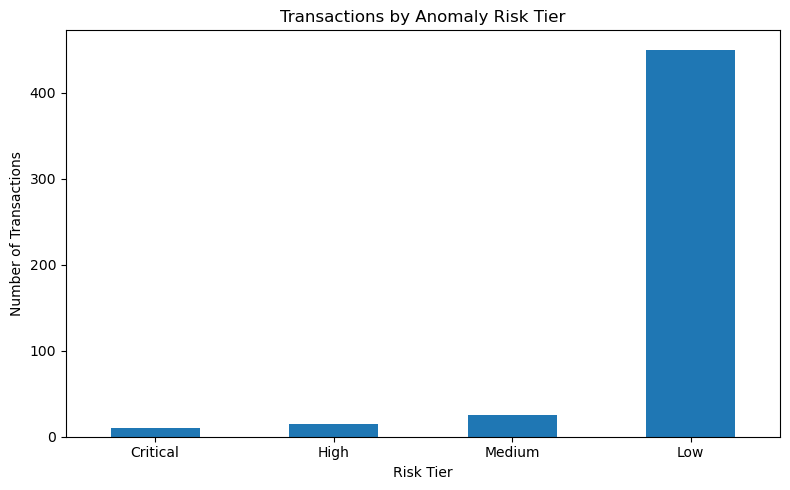

In [16]:
risk_distribution = (
    df["Risk Tier"]
    .value_counts()
    .reindex(["Critical", "High", "Medium", "Low"])
    .fillna(0)
    .astype(int)
)

display(risk_distribution.to_frame("Transactions"))

plt.figure(figsize=(8, 5))
risk_distribution.plot(kind="bar")
plt.title("Transactions by Anomaly Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [17]:
top_anomalies = df.sort_values(
    "Anomaly Score", ascending=False
).head(25)

display(
    top_anomalies[
        [
            "Anomaly Rank",
            "Timestamp",
            "From Bank",
            "To Bank",
            "Account",
            "Account_4",
            "Amount Received",
            "Receiving Currency",
            "Amount Paid",
            "Payment Currency",
            "Payment Format",
            "Currency Mismatch",
            "Is Laundering",
            "Anomaly Score",
            "Risk Tier",
        ]
    ]
)


,Anomaly Rank,Timestamp,From Bank,To Bank,Account,Account_4,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Currency Mismatch,Is Laundering,Anomaly Score,Risk Tier
422,1,2022-09-03 00:04:00,1,4,801227860,806ABFC50,4.016071e+09,Ruble,4.016071e+09,Ruble,Cheque,0,0,0.687038,Critical
432,2,2022-09-09 01:41:00,1,9,8023438C0,8060B3330,1.673041e+06,Ruble,1.673041e+06,Ruble,Credit Card,0,0,0.682727,Critical
421,3,2022-09-03 00:12:00,1,4,801227860,806ABFC50,2.981124e+09,Ruble,2.981124e+09,Ruble,ACH,0,0,0.682562,Critical
420,4,2022-09-05 14:08:00,1,4,801227860,806ABFC50,4.016071e+09,Ruble,4.016071e+09,Ruble,Cheque,0,0,0.682157,Critical
426,5,2022-09-06 07:13:00,1,4,801227860,806ABFC50,9.276020e+07,Ruble,9.276020e+07,Ruble,Credit Card,0,0,0.676908,Critical
427,6,2022-09-01 23:24:00,1,8,802921AF0,809F44000,2.960000e+01,Canadian Dollar,2.960000e+01,Canadian Dollar,ACH,0,0,0.672134,Critical
424,7,2022-09-02 18:23:00,1,4,8006AF880,806294390,2.146544e+06,Ruble,2.146544e+06,Ruble,Cash,0,0,0.671963,Critical
428,8,2022-09-06 21:12:00,1,8,802921AF0,809F44000,2.960000e+01,Canadian Dollar,2.960000e+01,Canadian Dollar,ACH,0,0,0.670632,Critical
425,9,2022-09-06 12:08:00,1,4,8006AF880,806294390,2.146544e+06,Ruble,2.146544e+06,Ruble,Cash,0,0,0.668500,Critical
430,10,2022-09-04 13:02:00,1,9,8023438C0,8060B3330,7.412305e+05,Ruble,7.412305e+05,Ruble,Cheque,0,0,0.667758,Critical


In [18]:
# Locate the labelled laundering transaction in the anomaly ranking.
if not labelled_cases.empty:
    labelled_index = labelled_cases.index[0]
    labelled_scored = df.loc[labelled_index]

    print("Labelled laundering anomaly rank:",
          int(labelled_scored["Anomaly Rank"]),
          "out of", len(df))
    print("Labelled laundering risk tier:",
          labelled_scored["Risk Tier"])
    print("Labelled laundering anomaly score:",
          round(labelled_scored["Anomaly Score"], 4))


Labelled laundering anomaly rank: 305 out of 500
Labelled laundering risk tier: Low
Labelled laundering anomaly score: 0.3995


### Predictive interpretation

The anomaly model highlights unusual combinations of:

- Transaction amount
- Received-versus-paid difference
- Time of transaction
- Currency combination
- Payment format
- Destination bank

It does not establish criminal intent. Every high-scoring transaction requires investigation and contextual evidence.


# Part D — Prescriptive Analytics


Prescriptive analytics converts findings into operational actions for compliance, data engineering, financial crime analytics, and model-risk teams.


In [19]:
prescriptive_actions = pd.DataFrame([
    {
        "Priority": "P0",
        "Action": "Human-review queue",
        "Recommendation": (
            "Review all Critical and High risk-tier transactions daily."
        ),
        "Owner": "Compliance Operations",
        "Timeline": "Immediate",
        "Success Measure": (
            "Review completion rate and confirmed suspicious rate"
        ),
    },
    {
        "Priority": "P0",
        "Action": "Currency normalization",
        "Recommendation": (
            "Convert received and paid values into one base currency "
            "using timestamp-aligned FX rates."
        ),
        "Owner": "Data Engineering",
        "Timeline": "1–2 weeks",
        "Success Measure": (
            "Percentage normalized and reconciliation error"
        ),
    },
    {
        "Priority": "P0",
        "Action": "Data enrichment",
        "Recommendation": (
            "Add KYC risk, customer country, transaction purpose, "
            "account age, beneficial owner, prior alerts, and case outcomes."
        ),
        "Owner": "Compliance and Data",
        "Timeline": "2–4 weeks",
        "Success Measure": "Feature coverage and missingness",
    },
    {
        "Priority": "P1",
        "Action": "Behavioural features",
        "Recommendation": (
            "Create one-hour, 24-hour and seven-day transaction count, "
            "value, velocity, round-amount, new-counterparty, fan-in, "
            "and fan-out indicators."
        ),
        "Owner": "Data Science",
        "Timeline": "2–4 weeks",
        "Success Measure": "Alert precision and recall",
    },
    {
        "Priority": "P1",
        "Action": "Network analytics",
        "Recommendation": (
            "Build account graphs to detect cycles, hubs, layering, "
            "rapid pass-through behaviour, and repeated account pairs."
        ),
        "Owner": "Financial Crime Analytics",
        "Timeline": "4–8 weeks",
        "Success Measure": "Suspicious clusters detected",
    },
    {
        "Priority": "P1",
        "Action": "Label improvement",
        "Recommendation": (
            "Capture investigator decisions, escalations, false positives, "
            "and suspicious activity report outcomes as reusable labels."
        ),
        "Owner": "Compliance Operations",
        "Timeline": "Ongoing",
        "Success Measure": "Positive labels and label turnaround time",
    },
    {
        "Priority": "P2",
        "Action": "Model governance",
        "Recommendation": (
            "Introduce time-based validation, explainability, drift "
            "monitoring, threshold approval, versioning, and audit trails."
        ),
        "Owner": "Model Risk",
        "Timeline": "6–10 weeks",
        "Success Measure": (
            "PR-AUC, recall at review capacity, and drift metrics"
        ),
    },
    {
        "Priority": "P2",
        "Action": "Threshold optimization",
        "Recommendation": (
            "Choose alert thresholds according to investigator capacity "
            "and the cost of missed cases and false positives."
        ),
        "Owner": "Compliance Leadership",
        "Timeline": "After label growth",
        "Success Measure": (
            "Cases per day, false-positive cost, missed-case estimate"
        ),
    },
])

display(prescriptive_actions)


,Priority,Action,Recommendation,Owner,Timeline,Success Measure
0,P0,Human-review queue,Review all Critical and High risk-tier transac...,Compliance Operations,Immediate,Review completion rate and confirmed suspiciou...
1,P0,Currency normalization,Convert received and paid values into one base...,Data Engineering,1–2 weeks,Percentage normalized and reconciliation error
2,P0,Data enrichment,"Add KYC risk, customer country, transaction pu...",Compliance and Data,2–4 weeks,Feature coverage and missingness
3,P1,Behavioural features,"Create one-hour, 24-hour and seven-day transac...",Data Science,2–4 weeks,Alert precision and recall
4,P1,Network analytics,"Build account graphs to detect cycles, hubs, l...",Financial Crime Analytics,4–8 weeks,Suspicious clusters detected
5,P1,Label improvement,"Capture investigator decisions, escalations, f...",Compliance Operations,Ongoing,Positive labels and label turnaround time
6,P2,Model governance,"Introduce time-based validation, explainabilit...",Model Risk,6–10 weeks,"PR-AUC, recall at review capacity, and drift m..."
7,P2,Threshold optimization,Choose alert thresholds according to investiga...,Compliance Leadership,After label growth,"Cases per day, false-positive cost, missed-cas..."


In [20]:
# Daily review queue for compliance investigators.
review_queue = (
    df[df["Risk Tier"].isin(["Critical", "High"])]
    .sort_values("Anomaly Score", ascending=False)
    [
        [
            "Anomaly Rank",
            "Timestamp",
            "Account",
            "Account_4",
            "From Bank",
            "To Bank",
            "Amount Received",
            "Receiving Currency",
            "Amount Paid",
            "Payment Currency",
            "Payment Format",
            "Currency Mismatch",
            "Anomaly Score",
            "Risk Tier",
            "Is Laundering",
        ]
    ]
)

display(review_queue)


,Anomaly Rank,Timestamp,Account,Account_4,From Bank,To Bank,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Currency Mismatch,Anomaly Score,Risk Tier,Is Laundering
422,1,2022-09-03 00:04:00,801227860,806ABFC50,1,4,4.016071e+09,Ruble,4.016071e+09,Ruble,Cheque,0,0.687038,Critical,0
432,2,2022-09-09 01:41:00,8023438C0,8060B3330,1,9,1.673041e+06,Ruble,1.673041e+06,Ruble,Credit Card,0,0.682727,Critical,0
421,3,2022-09-03 00:12:00,801227860,806ABFC50,1,4,2.981124e+09,Ruble,2.981124e+09,Ruble,ACH,0,0.682562,Critical,0
420,4,2022-09-05 14:08:00,801227860,806ABFC50,1,4,4.016071e+09,Ruble,4.016071e+09,Ruble,Cheque,0,0.682157,Critical,0
426,5,2022-09-06 07:13:00,801227860,806ABFC50,1,4,9.276020e+07,Ruble,9.276020e+07,Ruble,Credit Card,0,0.676908,Critical,0
427,6,2022-09-01 23:24:00,802921AF0,809F44000,1,8,2.960000e+01,Canadian Dollar,2.960000e+01,Canadian Dollar,ACH,0,0.672134,Critical,0
424,7,2022-09-02 18:23:00,8006AF880,806294390,1,4,2.146544e+06,Ruble,2.146544e+06,Ruble,Cash,0,0.671963,Critical,0
428,8,2022-09-06 21:12:00,802921AF0,809F44000,1,8,2.960000e+01,Canadian Dollar,2.960000e+01,Canadian Dollar,ACH,0,0.670632,Critical,0
425,9,2022-09-06 12:08:00,8006AF880,806294390,1,4,2.146544e+06,Ruble,2.146544e+06,Ruble,Cash,0,0.668500,Critical,0
430,10,2022-09-04 13:02:00,8023438C0,8060B3330,1,9,7.412305e+05,Ruble,7.412305e+05,Ruble,Cheque,0,0.667758,Critical,0


## 5. Export analytical outputs


In [21]:
OUTPUT_EXCEL = Path("aml_analytics_outputs.xlsx")
OUTPUT_CSV = Path("scored_transactions.csv")
REVIEW_QUEUE_CSV = Path("high_priority_review_queue.csv")

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    summary.to_excel(
        writer,
        sheet_name="Executive Summary",
        index=False,
    )
    payment_format_summary.to_excel(
        writer,
        sheet_name="Payment Formats",
        index=False,
    )
    receiving_currency_summary.to_excel(
        writer,
        sheet_name="Currencies",
        index=False,
    )
    destination_bank_summary.to_excel(
        writer,
        sheet_name="Destination Banks",
        index=False,
    )
    top_anomalies.to_excel(
        writer,
        sheet_name="Top Anomalies",
        index=False,
    )
    prescriptive_actions.to_excel(
        writer,
        sheet_name="Recommended Actions",
        index=False,
    )
    df.to_excel(
        writer,
        sheet_name="Scored Transactions",
        index=False,
    )

df.to_csv(OUTPUT_CSV, index=False)
review_queue.to_csv(REVIEW_QUEUE_CSV, index=False)

print("Created:", OUTPUT_EXCEL.resolve())
print("Created:", OUTPUT_CSV.resolve())
print("Created:", REVIEW_QUEUE_CSV.resolve())


Created: C:\Users\home\Downloads\Team-Management-System\IBM AML\aml_analytics_outputs.xlsx
Created: C:\Users\home\Downloads\Team-Management-System\IBM AML\scored_transactions.csv
Created: C:\Users\home\Downloads\Team-Management-System\IBM AML\high_priority_review_queue.csv


# Final conclusion

The dataset is useful for exploratory transaction analysis and anomaly-based review prioritization, but it is not sufficient for a reliable supervised laundering classifier.

The most important next step is not a more complex algorithm. It is the collection of better labels, historical account behaviour, KYC information, transaction purpose, geography, and network relationships.
